# Compas Analysis

What follows are the calculations performed for ProPublica's analysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

In [32]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [33]:
# Load Dataset

# Load the COMPAS dataset used in the original R script
# Using raw GitHub URL to ensure reproducibility

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

raw_data.shape

(7214, 53)

In [34]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [35]:
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select Relevant Variables
selected_cols = [
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid", "c_jail_in", "c_jail_out"
]

df = raw_data[selected_cols].copy()

# Data Filtering
df = df[
    df["days_b_screening_arrest"].between(-30, 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

# Data Type Conversion
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

categorical_cols = [col for col in df.columns if col not in numeric_vars + datetime_vars]
for col in categorical_cols:
    df[col] = df[col].astype("category")

# Create derived categorical variables
df["crime_factor"] = df["c_charge_degree"].astype("category")
df["age_factor"] = df["age_cat"].astype("category")
df["race_factor"] = df["race"].astype("category")
df["gender_factor"] = df["sex"].astype("category")
df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = df["score_factor"].astype("category")

# Create a binary prediction variable used in the fairness analysis
# Observations with Medium or High COMPAS scores are treated as high risk
df["high_risk"] = (df["score_text"] != "Low").astype(int)

df.shape[0]

6172

In [36]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,high_risk
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore,1


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

At this point, the cleaned COMPAS dataset is ready for the fairness audit.  
The remaining sections follow the lecture workflow and apply the required fairness metrics to the cleaned data.

# Setup and imports

This section loads the packages and confirms that the cleaned dataset contains the variables needed for the disparity audit.

In [38]:
# Install the SolasAI package used for the AIR comparison

# Install SolasAI disparity library if needed
!pip install solas-ai

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

In [39]:
# Quick check of the cleaned dataset and key variables used below
print(f"N = {len(df):,}")
print(df[["race", "sex", "high_risk", "two_year_recid"]].head())

N = 6,172
               race   sex  high_risk two_year_recid
0             Other  Male          0              0
1  African-American  Male          0              1
2  African-American  Male          0              1
5             Other  Male          0              0
6         Caucasian  Male          1              1


## AIR and Marginal Effect by race

### Compute AIR, ME, and SMD for race and sex separately
This section calculates selection rates, adverse impact ratio, and marginal effect by race, using Caucasian as the reference group.

In [40]:
def selection_rate(df, group_col, outcome_col, ref_group):
    """Selection rates, AIR, and ME relative to reference group"""
    rates = (
        df.groupby(group_col)[outcome_col]
        .mean()
        .rename("selection_rate")
        .reset_index()
    )

    # Get the selection rate for the reference group
    ref_rate = rates.loc[rates[group_col] == ref_group, "selection_rate"].values[0]

    # AIR measures the relative selection rate compared with the reference group
    rates["AIR"] = rates["selection_rate"] / ref_rate

    rates["ME"] = rates["selection_rate"] - ref_rate
    rates["flag_80"] = rates["AIR"].apply(lambda x: "*** BELOW 0.80" if x < 0.80 else "")
    return rates

sir_race = selection_rate(df, "race", "high_risk", ref_group="Caucasian")
print(sir_race.sort_values("AIR").to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               


/tmp/ipykernel_2083/1714703698.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [41]:
# Two-proportion z-test: Black vs. White
# Test whether the difference in selection rates between African-American and Caucasian groups is statistically significant
groups = ["African-American", "Caucasian"]
ns = df[df["race"].isin(groups)].groupby("race")["high_risk"].count()
events = df[df["race"].isin(groups)].groupby("race")["high_risk"].sum()
stat, pval = proportions_ztest(events[groups].values, ns[groups].values)

print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


/tmp/ipykernel_2083/1623874221.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_2083/1623874221.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The same AIR and ME calculation is then repeated for sex, using Male as the reference group.

In [42]:
# Repeat the same selection rate analysis for sex
sir_sex = selection_rate(df, "sex", "high_risk", ref_group="Male")
print(sir_sex.sort_values("AIR").to_string(index=False))

   sex  selection_rate      AIR        ME flag_80
Female        0.405106 0.889809 -0.050167        
  Male        0.455273 1.000000  0.000000        


/tmp/ipykernel_2083/1714703698.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [43]:
# Create binary indicator columns so the SolasAI function can read protected and reference groups in the expected format
df_solas = df.copy()

df_solas["African-American"] = (df_solas["race"] == "African-American").astype(int)
df_solas["Caucasian"] = (df_solas["race"] == "Caucasian").astype(int)
df_solas["Female"] = (df_solas["sex"] == "Female").astype(int)
df_solas["Male"] = (df_solas["sex"] == "Male").astype(int)

print(df_solas[["race", "African-American", "Caucasian"]].head())
print(df_solas[["sex", "Female", "Male"]].head())

               race  African-American  Caucasian
0             Other                 0          0
1  African-American                 1          0
2  African-American                 1          0
5             Other                 0          0
6         Caucasian                 0          1
    sex  Female  Male
0  Male       0     1
1  Male       0     1
2  Male       0     1
5  Male       0     1
6  Male       0     1


In [44]:
# Use SolasAI to compute AIR for race
# This is used to confirm that the package-based result is consistent with the manual calculation above
air_race_solas = sd.adverse_impact_ratio(
    group_data=df_solas,
    protected_groups=["African-American"],
    reference_groups=["Caucasian"],
    group_categories=["race"],
    outcome=df_solas["high_risk"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0,
)

print(air_race_solas)

+------------------------------+-------------------+
|       Protected Groups       | African-American  |
|       Reference Groups       |     Caucasian     |
|       Group Categories       |       race        |
|        AIR Threshold         |        0.8        |
| Percent Difference Threshold |        0.0        |
|       Shortfall Method       | to_reference_mean |
|       Affected Groups        |                   |
|      Affected Reference      |                   |
|     Affected Categories      |                   |
+------------------------------+-------------------+


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: Fut

In [45]:
# Use SolasAI to compute AIR for sex
# This confirms consistency with manual calculation for sex

air_sex_solas = sd.adverse_impact_ratio(
    group_data=df_solas,
    protected_groups=["Female"],
    reference_groups=["Male"],
    group_categories=["sex"],
    outcome=df_solas["high_risk"],
    sample_weight=None,
    air_threshold=0.80,
    percent_difference_threshold=0.0,
)

print(air_sex_solas)

+------------------------------+-------------------+
|       Protected Groups       |      Female       |
|       Reference Groups       |       Male        |
|       Group Categories       |        sex        |
|        AIR Threshold         |        0.8        |
| Percent Difference Threshold |        0.0        |
|       Shortfall Method       | to_reference_mean |
|       Affected Groups        |                   |
|      Affected Reference      |                   |
|     Affected Categories      |                   |
+------------------------------+-------------------+


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/usr/local/lib/python3.12/dist-packages/solas_disparity/disparity/_adverse_impact_ratio.py:205: Fut

In [46]:
# Compare the manual AIR results with the SolasAI outputs
print("Manual AIR by race")
print(sir_race.sort_values("AIR").to_string(index=False))

print("\nManual AIR by sex")
print(sir_sex.sort_values("AIR").to_string(index=False))

print("\nSolas AIR by race")
print(air_race_solas)

print("\nSolas AIR by sex")
print(air_sex_solas)

Manual AIR by race
            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               

Manual AIR by sex
   sex  selection_rate      AIR        ME flag_80
Female        0.405106 0.889809 -0.050167        
  Male        0.455273 1.000000  0.000000        

Solas AIR by race
+------------------------------+-------------------+
|       Protected Groups       | African-American  |
|       Reference Groups       |     Caucasian     |
|       Group Categories       |       race        |
|        AIR Threshold         |        0.8        |
| Percent Difference Threshold |        0.0        |
|     

The AIR computed using SolasAI matches the manual calculation, confirming that the implementation is correct.

Using high-risk classification as the outcome, the results show that African-American individuals are classified as high risk at a higher rate than Caucasian individuals.

The AIR results for sex are consistent between the manual and SolasAI calculations.

Using high-risk classification as the outcome, the results show a difference in how often male and female individuals are classified as high risk.

# Error-Rate Disparity Analysis

### Compute FPR and FNR disparities by race. Test statistical significance with a two-proportion z-test
Evaluating whether model error differs across racial groups by computing false positive rate, false negative rate, and overall accuracy.

In [47]:
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        results.append({
            group_col: grp,
            "n": len(g),
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else float("nan"),
            "FNR": fn / (fn + tp) if (fn + tp) > 0 else float("nan"),
            "Acc": (tp + tn) / len(g)
        })
    return pd.DataFrame(results)

# Compute group-level error rates by race
er = error_rates(df, "race", "high_risk", "two_year_recid")
print(er.sort_values("FPR", ascending=False).to_string(index=False))

/tmp/ipykernel_2083/695722396.py:3: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710


In [48]:
for grp in ["African-American", "Caucasian"]:
    row = er.loc[er["race"] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}, FNR={row['FNR'].values[0]:.3f}, Acc={row['Acc'].values[0]:.3f}")

African-American: FPR=0.423, FNR=0.285, Acc=0.649
Caucasian: FPR=0.220, FNR=0.496, Acc=0.672


In [49]:
# Compare false positive rates between African-American and Caucasian groups
# FPR z-test
black = df[df["race"] == "African-American"]
white = df[df["race"] == "Caucasian"]

fp_black = ((black["high_risk"] == 1) & (black["two_year_recid"] == 0)).sum()
neg_black = (black["two_year_recid"] == 0).sum()

fp_white = ((white["high_risk"] == 1) & (white["two_year_recid"] == 0)).sum()
neg_white = (white["two_year_recid"] == 0).sum()

stat_fpr, pval_fpr = proportions_ztest([fp_black, fp_white], [neg_black, neg_white])
print(f"FPR disparity test: z = {stat_fpr:.3f}, p = {pval_fpr:.4f}")

FPR disparity test: z = 11.384, p = 0.0000


In [50]:
# Compare false negative rates between African-American and Caucasian groups
# FNR z-test
fn_black = ((black["high_risk"] == 0) & (black["two_year_recid"] == 1)).sum()
pos_black = (black["two_year_recid"] == 1).sum()

fn_white = ((white["high_risk"] == 0) & (white["two_year_recid"] == 1)).sum()
pos_white = (white["two_year_recid"] == 1).sum()

stat_fnr, pval_fnr = proportions_ztest([fn_black, fn_white], [pos_black, pos_white])
print(f"FNR disparity test: z = {stat_fnr:.3f}, p = {pval_fnr:.4f}")

FNR disparity test: z = -10.370, p = 0.0000


The results show clear differences in both FPR and FNR across racial groups.

African-American individuals have a higher FPR, meaning they are more likely to be incorrectly classified as high risk when they do not reoffend. At the same time, Caucasian individuals have a higher FNR, meaning they are more likely to be incorrectly classified as low risk.
The two-proportion z-tests indicate that these differences are statistically significant (p < 0.05), suggesting that they are unlikely to be due to random variation.

Together, these results highlight that the model's errors are not evenly distributed across groups.

## Standardized Mean Difference
This step measures standardized score differences across groups using decile score and Cohen's d, with the reference group used as the comparison baseline.

In [51]:
# Compute standardized mean differences using decile score
# Showing how far each group's score distribution is from the reference group
def smd(df, group_col, score_col, ref_group):
    """Cohen's d vs. reference group"""
    ref = df.loc[df[group_col] == ref_group, score_col]
    results = []

    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue

        sc = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0

        mag = (
            "small" if abs(d) < 0.2
            else "medium" if abs(d) < 0.5
            else "large" if abs(d) < 0.8
            else "very large"
        )

        results.append({
            group_col: grp,
            "mean_score": round(sc.mean(), 3),
            "SMD": round(d, 3),
            "magnitude": mag
        })

    return pd.DataFrame(results)

# Compute SMD for race relative to the Caucasian reference group
smd_race = smd(df, "race", "decile_score", ref_group="Caucasian")
print(smd_race.sort_values("SMD", ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


/tmp/ipykernel_2083/3952764604.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [52]:
# Compute SMD for sex relative to the male reference group
smd_sex = smd(df, "sex", "decile_score", ref_group="Male")
print(smd_sex.sort_values("SMD", ascending=False).to_string(index=False))

   sex  mean_score    SMD magnitude
Female       4.064 -0.158     small


/tmp/ipykernel_2083/3952764604.py:8: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



The ME and SMD metrics provide additional ways to evaluate disparity.

ME reflects the absolute difference in the rate of being classified as high risk, while SMD standardizes this difference across groups.

These results are consistent with the AIR findings and further indicate differences between groups.

Since ME and SMD are derived from the same underlying rates, the results are expected to be consistent with package-based implementations.

## Intersectional Subgroup Analysis

### Build an intersectional analysis (race ×sex). Report the worst-group AIR and interpret it.

This combines race and sex to examine whether disparities become larger when groups are evaluated at the intersection of multiple attributes.

In [53]:
# Create intersectional subgroups by combining race and sex
df["subgroup"] = df["race"].astype(str) + " / " + df["sex"].astype(str)

# Keep only subgroups with at least 30 observations
counts = df["subgroup"].value_counts()
valid_sg = counts[counts >= 30].index
df_sub = df[df["subgroup"].isin(valid_sg)].copy()

# Compute subgroup selection rates
sub_rates = (
    df_sub.groupby("subgroup")["high_risk"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "selection_rate", "count": "n"})
    .reset_index()
)

# Use Caucasian or Male as the reference subgroup
ref_rate = sub_rates.loc[
    sub_rates["subgroup"] == "Caucasian / Male",
    "selection_rate"
].values[0]

sub_rates["AIR"] = sub_rates["selection_rate"] / ref_rate
sub_rates["flag"] = sub_rates["AIR"].apply(lambda x: "*** BELOW 0.80" if x < 0.80 else "")

print(sub_rates.sort_values("AIR").to_string(index=False))

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               


In [54]:
# Identify the subgroup with the lowest AIR
worst = sub_rates.loc[sub_rates["AIR"].idxmin()]
print(f"Worst group: {worst['subgroup']}")
print(f"AIR: {worst['AIR']:.3f}")
print(f"Selection rate: {worst['selection_rate']:.3f}")
print(f"n: {worst['n']}")

Worst group: Hispanic / Female
AIR: 0.270
Selection rate: 0.085
n: 82


The subgroup with the lowest AIR is Hispanic females, with an AIR of 0.270.

Using high-risk classification as the outcome, this means that Hispanic females are classified as high risk at a much lower rate than the reference group. Their selection rate is 0.085, which is notably low compared to other subgroups.

This result shows that patterns can change when race and sex are considered together, and highlights the importance of examining intersectional groups.

## Produce a publication-quality figure: grouped bar chart


The figure shows differences in both FPR and FNR across racial groups, with Caucasian used as the reference group.

African-American individuals have a higher FPR, while Caucasian individuals have a higher FNR, indicating that different types of errors are distributed unevenly across groups.

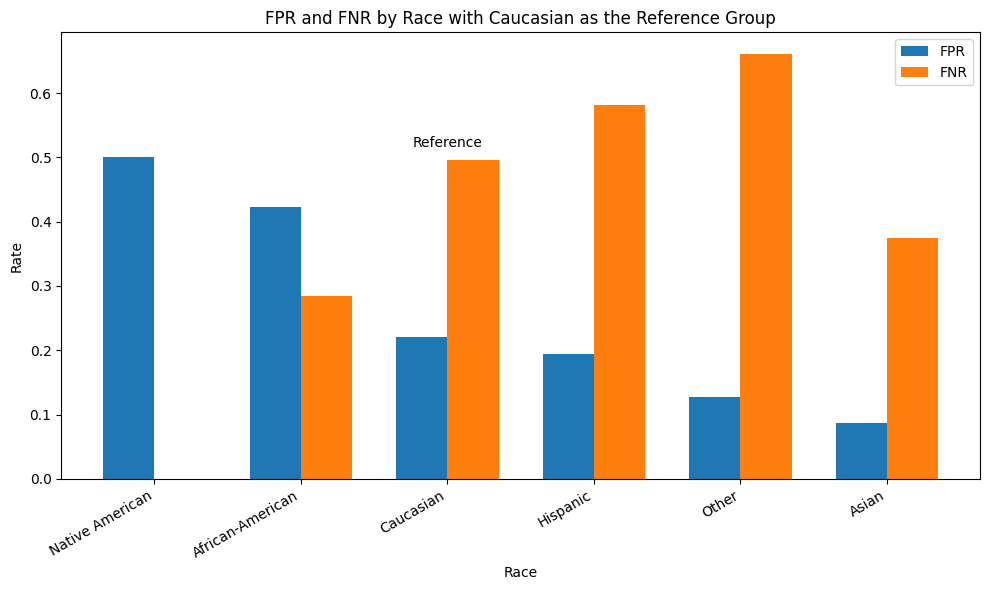

In [55]:
# Create a grouped bar chart of FPR and FNR by race
plot_df = er.copy().sort_values("FPR", ascending=False).reset_index(drop=True)

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, plot_df["FPR"], width, label="FPR")
ax.bar(x + width/2, plot_df["FNR"], width, label="FNR")

ax.set_xticks(x)
ax.set_xticklabels(plot_df["race"], rotation=30, ha="right")
ax.set_ylabel("Rate")
ax.set_xlabel("Race")
ax.set_title("FPR and FNR by Race with Caucasian as the Reference Group")
ax.legend()

for i, race in enumerate(plot_df["race"]):
    if race == "Caucasian":
        ax.text(i, max(plot_df.loc[i, "FPR"], plot_df.loc[i, "FNR"]) + 0.02, "Reference", ha="center")

plt.tight_layout()
plt.show()

## Compliance Memo

This memo reviews the fairness of a recidivism prediction model built on the COMPAS dataset, with a focus on whether outcomes differ across demographic groups.

From the results, there are clear differences across both race and sex. In terms of race, the AIR shows that African-American individuals are classified as high risk more often than Caucasian individuals. For sex, there is also a difference, although it is smaller in magnitude.

Looking at race and sex together makes the pattern more noticeable. Hispanic females have the lowest AIR at 0.270, and their selection rate is only 0.085. This means they are classified as high risk much less often than the reference group. This highlights how results can change when considering intersectional groups instead of looking at race or sex separately.

The error metrics provide additional insight. African-American individuals have a higher false positive rate, meaning they are more likely to be incorrectly labeled as high risk. In contrast, Caucasian individuals have a higher false negative rate, meaning they are more likely to be incorrectly labeled as low risk. The statistical tests show that these differences are significant and not likely due to chance.

There are also limitations to consider. The results depend on the dataset and the features used, which may reflect existing biases. In addition, different fairness metrics capture different aspects of disparity, so no single metric provides a complete picture.

Overall, the results suggest that the model produces uneven outcomes across groups. These patterns should be carefully reviewed before the model is used in real-world decision-making.